

This notebook documents the executable analysis workflow underlying the
graduation thesis *“Data-Driven Analysis of Potato Flavour and Aroma Using
TD–GC–MS and Machine Learning”*.

The focus of this notebook is to:
  
- Evaluate genetic predictability of aroma compounds for independent generalisation check
_ This notebook should be run by  genemarker_module.py

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f
import yaml
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
import os
import time

# Data Loading

In [7]:


with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Paths for Biorep1
genetic_path = config["biorep2"]["data"]["genetic_data"]
aroma_path   = config["biorep2"]["data_paths"]["aroma_matrix_output"]
pc_df_path   = config["biorep2"]["data"]["sensory_data"]

# Load data
genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
sensory_pcs = pd.read_excel(pc_df_path)


# Remove duplicate columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.duplicated()]


#  Remove useless 'Unnamed:' columns
sensory_pcs = sensory_pcs.loc[:, ~sensory_pcs.columns.str.contains("Unnamed")]


#  Normalize the Variety column name
if "VARIETY" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"VARIETY": "Variety"})
elif "Variety_original" in sensory_pcs.columns:
    sensory_pcs = sensory_pcs.rename(columns={"Variety_original": "Variety"})

# Double-check the result
print("Final sensory PCA columns:", sensory_pcs.columns.tolist())
print("Variety exists:", "Variety" in sensory_pcs.columns)


Final sensory PCA columns: ['Variety', 'Variety_original', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, cluster 2 UK.1'

# Alignment and merging of genotype and phenotype tables


In [8]:

from genemarker_module import merge_genetic_aroma_sensory

# Clean Variety labels consistently
sensory_pcs["Variety"] = sensory_pcs["Variety"].astype(str).str.strip()
aroma_df["Variety"]  = aroma_df["Variety"].astype(str).str.strip()

# If sensory has duplicates per Variety, average numeric columns
sensory_pcs = (sensory_pcs
               .groupby("Variety", as_index=False)
               .mean(numeric_only=True))

print("Sensory after grouping:", sensory_pcs.shape,
      "| unique varieties:", sensory_pcs["Variety"].nunique())


# Run merge function 
merged_snp_aroma2, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_df, sensory_pcs
)
out_path = (
 
    "merged_snp_sensory_biorep2.csv"
)
merged_snp_aroma2.to_csv(out_path, index=False)

print(f"Saved biorep2 merged file to: {out_path}")

Sensory after grouping: (59, 15) | unique varieties: 59
 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 62
  Dropped (all NaN): 0
  Final usable aroma columns: 62
  Sample aroma cols: ['Unnamed: 0', '(E)-2-Heptenal', '1-Heptanol', '1-Hexanol, 2-ethyl-', '1-Nonanol', '1-Phenylethanol', '2(3H)-Furanone, dihydro-5-pentyl-', '2,3-Butanedione']

# Sensory PCs: 14
Sample sensory cols: ['cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, cluster 2 UK.1', 'number ID', 'citric acid']

# Merge results:
  Genetic + Aroma: (94, 262496)
  Genetic + Sensory: (20, 262448)
  Genetic + Aroma + Sensory: (94, 262510)
Saved biorep2 merged file to: merged_snp_sensory_biorep2.csv


# Independent generalisation check by best model of aroma prediction in biorep1

# Linear models

In [9]:

from genemarker_module import run_linear_models_independent_generalisation_with_params


# Helpers
def drop_unnamed(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.columns.astype(str)
    drop_cols = [c for c in cols if c.lower().startswith("unnamed")]
    return df.drop(columns=drop_cols, errors="ignore")


def gen_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns.astype(str) if c.startswith("GEN__")]


def ensure_variety_alignment(train_df: pd.DataFrame, indep_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Align rows by Variety using indep_df.index as Variety names.
    This assumes both datasets contain the same varieties but train_df lost Variety info.
    """
    indep_varieties = indep_df.index.astype(str).tolist()

    if len(train_df) != len(indep_df):
        raise ValueError(f"Row count mismatch: train={len(train_df)} indep={len(indep_df)}")

    # Attach Variety to train based on indep index order
    train_fixed = train_df.copy().reset_index(drop=True)
    train_fixed["Variety"] = indep_varieties

    # Attach Variety to indep explicitly (from index)
    indep_fixed = indep_df.copy()
    indep_fixed["Variety"] = indep_fixed.index.astype(str)

    # Sort both by Variety and verify identical order
    train_fixed = train_fixed.sort_values("Variety").reset_index(drop=True)
    indep_fixed = indep_fixed.sort_values("Variety").reset_index(drop=True)

    if train_fixed["Variety"].tolist() != indep_fixed["Variety"].tolist():
        raise ValueError("Variety alignment failed after sorting (Variety lists differ).")

    return train_fixed, indep_fixed


def make_df_unique_traits(df_linear_cv: pd.DataFrame) -> pd.DataFrame:
    """
    Clean CV table and return 1 row per Trait for iteration.
    """
    df = df_linear_cv.copy()
    df = drop_unnamed(df)

    if "Trait" not in df.columns:
        raise ValueError("Trait column not found in df_linear_cv_biorep1")

    df["Trait"] = df["Trait"].astype(str)
    df = df[df["Trait"].str.lower().ne("unnamed: 0")]
    df = df[df["Trait"].str.lower().ne("nan")]
    df = df[df["Trait"].str.strip().ne("")]

    df_unique = df.drop_duplicates(subset=["Trait"], keep="first").reset_index(drop=True)
    return df_unique



df_linear_cv_path = config["biorep1"]["data"]["df_linear_cv_biorep1_output"]
df_linear_cv_biorep1 = pd.read_csv(df_linear_cv_path)
gwas_file_train = config["biorep1"]["data"]["gwas_output_gene_aroma"]
snp_biorep1 = pd.read_csv(
    config["biorep1"]["data"]["merged_snp_aroma_output"])


# Clean inputs
df_linear_cv_biorep1 = drop_unnamed(df_linear_cv_biorep1)
snp_biorep1 = drop_unnamed(snp_biorep1)
merged_snp_aroma2 = drop_unnamed(merged_snp_aroma2)

# Unique traits list (for loop)
df_unique = make_df_unique_traits(df_linear_cv_biorep1)
print("rows original:", len(df_linear_cv_biorep1))
print("unique traits:", df_unique["Trait"].nunique())
print("rows after unique:", len(df_unique))

# Align train/indep by Variety (using indep index as Variety names)
train_fixed, indep_fixed = ensure_variety_alignment(snp_biorep1, merged_snp_aroma2)

# Common GEN__ columns
GEN_TRAIN = gen_cols(train_fixed)
GEN_INDEP = gen_cols(indep_fixed)
COMMON_GEN = sorted(list(set(GEN_TRAIN) & set(GEN_INDEP)))

print("train rows:", len(train_fixed), "| indep rows:", len(indep_fixed))
print("common GEN__:", len(COMMON_GEN))



# Run independent evaluation (trait-by-trait, leakage-safe)
results = []
t_start = time.time()

N_SNPS = 300        
PRUNE = 0.95         

for i in range(len(df_unique)):
    trait = str(df_unique.loc[i, "Trait"])

    # CV rows for this trait (IMPORTANT: must include Model + CV_R2; alpha/l1_ratio if available)
    df_cv_trait = df_linear_cv_biorep1[df_linear_cv_biorep1["Trait"].astype(str) == trait].copy()
    if df_cv_trait.empty:
        print(f"[{i+1}/{len(df_unique)}] trait={trait}  SKIP (no CV rows found)")
        continue

    # Trait column must exist in merged tables (as y)
    if trait not in train_fixed.columns or trait not in indep_fixed.columns:
        print(f"[{i+1}/{len(df_unique)}] trait={trait}  SKIP (trait column missing in merged tables)")
        continue

    # Build minimal safe tables:
    #   X = GEN__ only
    #   y = ONLY this trait
    snp_train_min = train_fixed.loc[:, ["Variety"] + COMMON_GEN + [trait]].copy()
    snp_indep_min = indep_fixed.loc[:, ["Variety"] + COMMON_GEN + [trait]].copy()

    t0 = time.time()
    out = run_linear_models_independent_generalisation_with_params(
        df_linear_cv=df_cv_trait,      # <-- correct CV table for that trait
        gwas_file=gwas_file_train,
        snp_train=snp_train_min,
        snp_indep=snp_indep_min,
        n_snps=N_SNPS,
        prune_threshold=PRUNE
    )
    dt = time.time() - t0

    status = "OK"
    if out is None:
        status = "out=None"
    elif isinstance(out, pd.DataFrame) and out.empty:
        status = "out=empty"

    print(f"[{i+1}/{len(df_unique)}] trait={trait}  time={dt:.1f}s  {status}")

    if out is not None and isinstance(out, pd.DataFrame) and not out.empty:
        results.append(out)

df_linear_independent = pd.concat(results, ignore_index=True) if results else pd.DataFrame()

print("TOTAL minutes:", (time.time() - t_start) / 60)
print("final shape:", df_linear_independent.shape)
print("final columns:", df_linear_independent.columns.tolist())

display(df_linear_independent.head(10))


# Summaries 
if not df_linear_independent.empty and "R2" in df_linear_independent.columns:
    display(df_linear_independent["R2"].describe())
    display(df_linear_independent.sort_values("R2", ascending=False).head(10)[["Trait","Model","R2","RMSE","MAE"]])
    display(df_linear_independent.sort_values("R2", ascending=True).head(10)[["Trait","Model","R2","RMSE","MAE"]])
    print("n(R2<0):", (df_linear_independent["R2"] < 0).sum())


# Save
out_path = config["biorep2"]["data"].get(
    "df_linear_independent_output",
    f"df_linear_independent_biorep1_to_biorep2_top{N_SNPS}_prune{PRUNE}.csv"
)
out_dir = os.path.dirname(out_path)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

df_linear_independent.to_csv(out_path, index=False)
print("Saved:", out_path)


rows original: 268
unique traits: 66
rows after unique: 66
train rows: 94 | indep rows: 94
common GEN__: 262434
[1/66] trait=(E)-2-Decenal  SKIP (trait column missing in merged tables)
[2/66] trait=(E, E)-2,4-Decadienal  SKIP (trait column missing in merged tables)
[3/66] trait=1-Heptanol  time=0.7s  OK
[4/66] trait=1-Nonanol  time=0.4s  OK
[5/66] trait=1-Octen-3-ol  SKIP (trait column missing in merged tables)
[6/66] trait=1-Penten-3-one  SKIP (trait column missing in merged tables)
[7/66] trait=1-Phenylethanol  time=0.6s  OK
[8/66] trait=2(3H)-Furanone, dihydro-5-pentyl-  time=0.4s  OK
[9/66] trait=2,3-Butanedione  time=0.3s  OK
[10/66] trait=2,4-Heptadienal  SKIP (trait column missing in merged tables)
[11/66] trait=2-Acetyl-5-methylfuran  SKIP (trait column missing in merged tables)
[12/66] trait=2-Decanone  SKIP (trait column missing in merged tables)
[13/66] trait=2-Ethylfuran  time=0.3s  OK
[14/66] trait=2-Heptanone  time=0.3s  OK
[15/66] trait=2-Methylbutanal  time=0.3s  OK
[16

,Trait,Model,R2,RMSE,MAE
0,1-Heptanol,Ridge,-15.178226,4.677697e+05,2.427968e+05
1,1-Nonanol,Ridge,-78.759223,2.748426e+05,1.281768e+05
2,1-Phenylethanol,ElasticNet,-21.774081,7.264363e+04,3.796152e+04
3,"2(3H)-Furanone, dihydro-5-pentyl-",Ridge,-2.599974,1.250358e+06,7.001000e+05
4,"2,3-Butanedione",Ridge,-1.140303,1.055452e+06,8.522310e+05
5,2-Ethylfuran,Ridge,-0.363132,4.002212e+05,1.985991e+05
6,2-Heptanone,Ridge,-4821.148452,1.788059e+06,1.508392e+06
7,2-Methylbutanal,Ridge,-10.852568,2.346166e+05,1.690325e+05
8,2-Methylpropanal,Ridge,-4.173340,8.788424e+05,6.505357e+05
9,2-Nonanone,ElasticNet,-12.290924,3.626519e+05,2.109864e+05


count      51.000000
mean     -150.306092
std       699.287080
min     -4821.148452
25%       -23.827701
50%        -4.295070
75%        -1.636764
max         0.337130
Name: R2, dtype: float64

,Trait,Model,R2,RMSE,MAE
22,"Butanal, 3-methyl-",Ridge,0.337130,2.137906e+05,1.122693e+05
38,Nonanal,Ridge,0.337130,2.137906e+05,1.122693e+05
15,3-Methylbutanal,Ridge,0.172845,1.930796e+06,1.383043e+06
32,"Furan, 2-pentyl-",Ridge,-0.198911,1.497940e+06,7.547151e+05
5,2-Ethylfuran,Ridge,-0.363132,4.002212e+05,1.985991e+05
33,Furfural,Ridge,-1.010284,3.031852e+05,2.060755e+05
13,3-Furaldehyde,Ridge,-1.010284,3.031852e+05,2.060755e+05
20,"Benzoic acid, methyl ester",Ridge,-1.105576,3.785900e+05,2.919623e+05
17,"Acetic acid, ethenyl ester",Ridge,-1.140303,1.055452e+06,8.522310e+05
4,"2,3-Butanedione",Ridge,-1.140303,1.055452e+06,8.522310e+05


,Trait,Model,R2,RMSE,MAE
6,2-Heptanone,Ridge,-4821.148452,1.788059e+06,1.508392e+06
40,Octanoic acid,Ridge,-1385.368143,7.925392e+05,3.759606e+05
45,Propanoic acid,Ridge,-597.730668,1.558199e+06,8.581021e+05
36,Hexanol,Ridge,-232.849912,4.893400e+05,3.829069e+05
1,1-Nonanol,Ridge,-78.759223,2.748426e+05,1.281768e+05
48,Tridecanal,Ridge,-72.359768,1.784442e+06,9.119529e+05
24,Decanal,Ridge,-72.359768,1.784442e+06,9.119529e+05
26,Dimethyl phthalate,Ridge,-56.035892,4.430195e+06,2.260401e+06
30,"Ethanol, 2-phenoxy-",ElasticNet,-44.648492,2.600459e+06,1.135000e+06
29,Dodecanoic acid,Ridge,-38.818599,5.499831e+05,3.302016e+05


n(R2<0): 48
Saved: df_linear_independent_biorep1_to_biorep2_top300_prune0.95.csv


<Figure size 700x500 with 0 Axes>

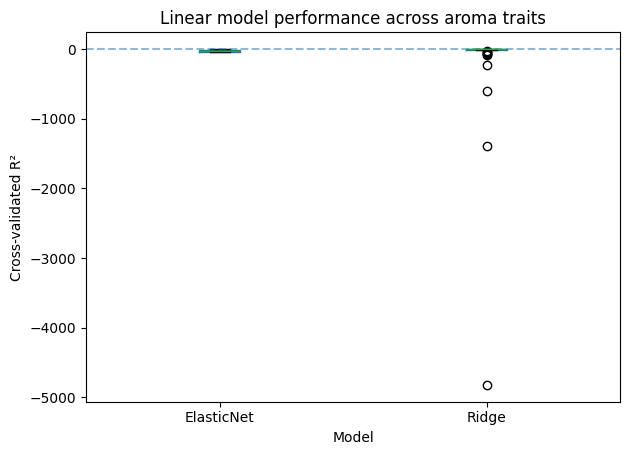

In [10]:
plt.figure(figsize=(7, 5))
df_linear_independent.boxplot(column="R2", by="Model", grid=False)
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Linear model performance across aroma traits")
plt.suptitle("")
plt.ylabel("Cross-validated R²")
plt.tight_layout()
plt.show()